# Задача: Отобразить высокомерные данные $X ∈ ℝ^D$ в низкомерное пространство $Y ∈ ℝ^d (d=2,3)$ так, чтобы сохранить структуру соседства.

    1. Вероятностная постановка задачи


Задача: Отобразить высокомерные данные X ∈ ℝ^D в низкомерное пространство Y ∈ ℝ^d (d=2,3) 
так, чтобы сохранить структуру соседства.


        - Вероятности в исходном пространстве

Гауссово ядро для измерения сходства:

$
p_{j|i} = exp(-||x_i - x_j||^2 / (2σ_i^2)) / Σ_{k≠i} exp(-||x_i - x_k||^2 / (2σ_i^2))$

Симметризация вероятностей:

$
p_{ij} = (p_{j|i} + p_{i|j}) / (2n)$

Перплексия (perplexity) как гиперпараметр:

$
Perp(P_i) = 2^{H(P_i)}, $

где $H(P_i) = -Σ_j p_{j|i} log₂ p_{j|i}$

        - Вероятности в целевом пространстве

Распределение Стьюдента с одной степенью свободы:

$
q_{ij} = (1 + ||y_i - y_j||^2)^{-1} / Σ_{k≠l} (1 + ||y_k - y_l||^2)^{-1}$

Преимущества t-распределения:

       * Тяжелые хвосты

       * Устойчивость к проклятию размерности

       * Улучшенное разделение кластеров

       * Функция стоимости (KL-дивергенция)
 
$C(Y) = KL(P||Q) = Σ_i Σ_j p_{ij} log(p_{ij} / q_{ij})$

    2. Оптимизация функции стоимости

        2.1. Градиент функции стоимости

$∂C/∂y_i = 4 Σ_j (p_{ij} - q_{ij})(y_i - y_j)(1 + ||y_i - y_j||^2)^{-1}$

       2.2. Методы оптимизации

Градиентный спуск с моментумом:

$Y^{(t)} = Y^{(t-1)} + η ∂C/∂Y + α(t)(Y^{(t-1)} - Y^{(t-2)})$


Раннее преувеличение (early exaggeration):

 
$p_{ij} ← p_{ij} × 4 (первые 100 итераций)$


Адаптивное обучение (adaptive learning rate)

        2.3. Сложности оптимизации

            - Невыпуклость функции стоимости

            - Локальные минимумы

            - Чувствительность к начальной инициализации

            - Вычислительная сложность O(n²)

Импорт библиотек

In [11]:
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
from sklearn.metrics import pairwise_distances


# Задание

1. Провести исследование влияния гиперпараметров на результаты кластеризации с T-SNE
2. Сравнить с PCA 
   
Использовать 2 датасета - стандартного типа Ирис или Цифры, и своего. Не забываем про нормировку и eda в целом

In [12]:
custom_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
custom_df = pd.read_csv(custom_url)
custom_target_col = "species"

custom_df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [13]:
digits = load_digits()
digits_df = pd.DataFrame(digits.data, columns=[f"pixel_{i}" for i in range(digits.data.shape[1])])
digits_df["target"] = digits.target

datasets = {
    "Digits": (digits_df, "target"),
    "Custom": (custom_df, custom_target_col)
}

for name, (data, target_col) in datasets.items():
    print(name)
    print("Размер:", data.shape)
    print("Пропуски:", int(data.isna().sum().sum()))
    print("Целевая переменная:", target_col)
    display(data.describe(include="all").T.head(12))


Digits
Размер: (1797, 65)
Пропуски: 0
Целевая переменная: target


,count,mean,std,min,25%,50%,75%,max
pixel_0,1797.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
pixel_1,1797.0,0.303840,0.907192,0.0,0.0,0.0,0.0,8.0
pixel_2,1797.0,5.204786,4.754826,0.0,1.0,4.0,9.0,16.0
pixel_3,1797.0,11.835838,4.248842,0.0,10.0,13.0,15.0,16.0
pixel_4,1797.0,11.848080,4.287388,0.0,10.0,13.0,15.0,16.0
pixel_5,1797.0,5.781859,5.666418,0.0,0.0,4.0,11.0,16.0
pixel_6,1797.0,1.362270,3.325775,0.0,0.0,0.0,0.0,16.0
pixel_7,1797.0,0.129661,1.037383,0.0,0.0,0.0,0.0,15.0
pixel_8,1797.0,0.005565,0.094222,0.0,0.0,0.0,0.0,2.0
pixel_9,1797.0,1.993879,3.196160,0.0,0.0,0.0,3.0,16.0


Custom
Размер: (344, 7)
Пропуски: 19
Целевая переменная: species


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
species,344,3,Adelie,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
island,344,3,Biscoe,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bill_length_mm,342.0,NaN,NaN,NaN,43.92193,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,NaN,NaN,NaN,17.15117,1.974793,13.1,15.6,17.3,18.7,21.5
flipper_length_mm,342.0,NaN,NaN,NaN,200.915205,14.061714,172.0,190.0,197.0,213.0,231.0
body_mass_g,342.0,NaN,NaN,NaN,4201.754386,801.954536,2700.0,3550.0,4050.0,4750.0,6300.0
sex,333,2,MALE,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Разделить выборку на фичи и целевую переменную

In [14]:
prepared = {}

for name, (data, target_col) in datasets.items():
    features = data.drop(columns=[target_col]).select_dtypes(include=[np.number]).copy()
    target = data[target_col].copy()

    if not pd.api.types.is_numeric_dtype(target):
        target = pd.Series(pd.factorize(target)[0], index=target.index, name=target_col)

    valid_rows = features.notna().all(axis=1) & target.notna()
    features = features.loc[valid_rows]
    target = target.loc[valid_rows].astype(int)

    prepared[name] = {
        "feature_cols": features.columns.tolist(),
        "X": features.to_numpy(),
        "y": target.to_numpy(),
        "target_col": target_col
    }

selected_name = "Digits"
feature_cols = prepared[selected_name]["feature_cols"]
X = prepared[selected_name]["X"]
y = prepared[selected_name]["y"]

print(selected_name, X.shape, y.shape)


Digits (1797, 64) (1797,)


Нормировка

In [15]:
scalers = {}

for name, item in prepared.items():
    scaler = StandardScaler()
    item["X_scaled"] = scaler.fit_transform(item["X"])
    scalers[name] = scaler

scaler = scalers[selected_name]
X_scaled = prepared[selected_name]["X_scaled"]

print(np.round(X_scaled.mean(axis=0)[:5], 4))
print(np.round(X_scaled.std(axis=0)[:5], 4))


[ 0. -0.  0.  0. -0.]
[0. 1. 1. 1. 1.]


pca = PCA(n_components=2, random_state=42)

Digits
Доля объяснённой дисперсии: [0.12033916 0.09561054] Суммарно: 0.2159497050083281
Custom
Доля объяснённой дисперсии: [0.68843878 0.19312919] Суммарно: 0.8815679694372629


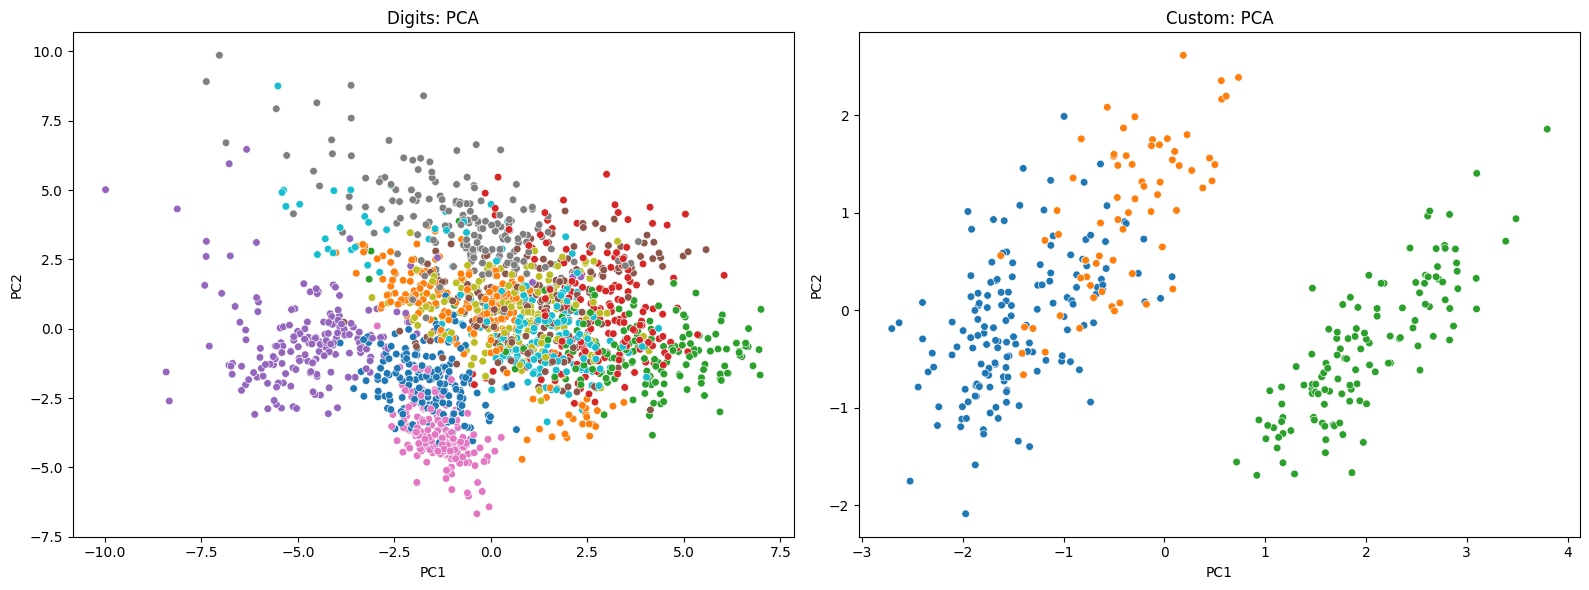

In [16]:
pca_results = {}
fig, axes = plt.subplots(1, len(prepared), figsize=(8 * len(prepared), 6))
axes = np.atleast_1d(axes)

for ax, (name, item) in zip(axes, prepared.items()):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(item["X_scaled"])
    item["X_pca"] = X_pca
    pca_results[name] = pca

    print(name)
    print("Доля объяснённой дисперсии:", pca.explained_variance_ratio_, "Суммарно:", pca.explained_variance_ratio_.sum())
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=item["y"], palette="tab10", s=30, ax=ax, legend=False)
    ax.set_title(f"{name}: PCA")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

X_pca = prepared[selected_name]["X_pca"]
pca = pca_results[selected_name]
plt.tight_layout()
plt.show()


TSNE 2 компоненты

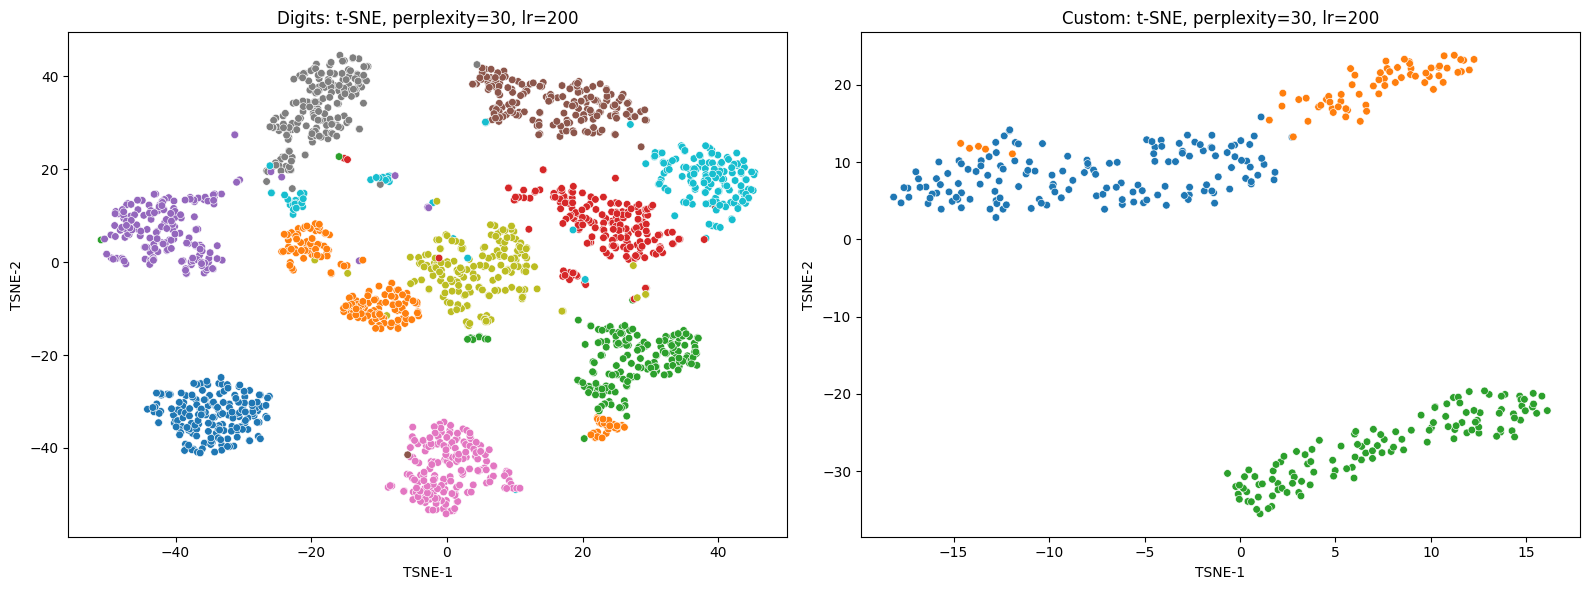

In [17]:
def make_tsne(perplexity=30, learning_rate=200, random_state=42, max_iter=750):
    params = {
        "n_components": 2,
        "perplexity": perplexity,
        "learning_rate": learning_rate,
        "init": "pca",
        "random_state": random_state
    }
    if "max_iter" in inspect.signature(TSNE).parameters:
        params["max_iter"] = max_iter
    else:
        params["n_iter"] = max_iter
    return TSNE(**params)

tsne_results = {}
fig, axes = plt.subplots(1, len(prepared), figsize=(8 * len(prepared), 6))
axes = np.atleast_1d(axes)

for ax, (name, item) in zip(axes, prepared.items()):
    perp = min(30, max(1, (len(item["X_scaled"]) - 1) // 3))
    tsne = make_tsne(perplexity=perp, learning_rate=200, max_iter=750)
    X_tsne = tsne.fit_transform(item["X_scaled"])
    item["X_tsne"] = X_tsne
    tsne_results[name] = tsne

    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=item["y"], palette="tab10", s=30, ax=ax, legend=False)
    ax.set_title(f"{name}: t-SNE, perplexity={perp}, lr=200")
    ax.set_xlabel("TSNE-1")
    ax.set_ylabel("TSNE-2")

X_tsne = prepared[selected_name]["X_tsne"]
tsne = tsne_results[selected_name]
plt.tight_layout()
plt.show()


In [18]:
def separation_score(X_2d, y):
    D = pairwise_distances(X_2d)
    same_mask = (y[:, None] == y[None, :]) & ~np.eye(len(y), dtype=bool)
    diff_mask = y[:, None] != y[None, :]
    same = D[same_mask]
    diff = D[diff_mask]
    return same.mean(), diff.mean(), diff.mean() / same.mean()

score_rows = []

for name, item in prepared.items():
    pca_same, pca_diff, pca_ratio = separation_score(item["X_pca"], item["y"])
    tsne_same, tsne_diff, tsne_ratio = separation_score(item["X_tsne"], item["y"])
    score_rows.extend([
        {"dataset": name, "method": "PCA", "same": pca_same, "diff": pca_diff, "ratio": pca_ratio},
        {"dataset": name, "method": "t-SNE", "same": tsne_same, "diff": tsne_diff, "ratio": tsne_ratio}
    ])

scores = pd.DataFrame(score_rows)
scores


,dataset,method,same,diff,ratio
0,Digits,PCA,2.482044,4.761456,1.918361
1,Digits,t-SNE,12.537442,50.062489,3.993038
2,Custom,PCA,1.115250,2.989710,2.680752
3,Custom,t-SNE,7.929400,35.329510,4.455508


Вычислить и отрисовать T-SNE с разным значением Perplexity

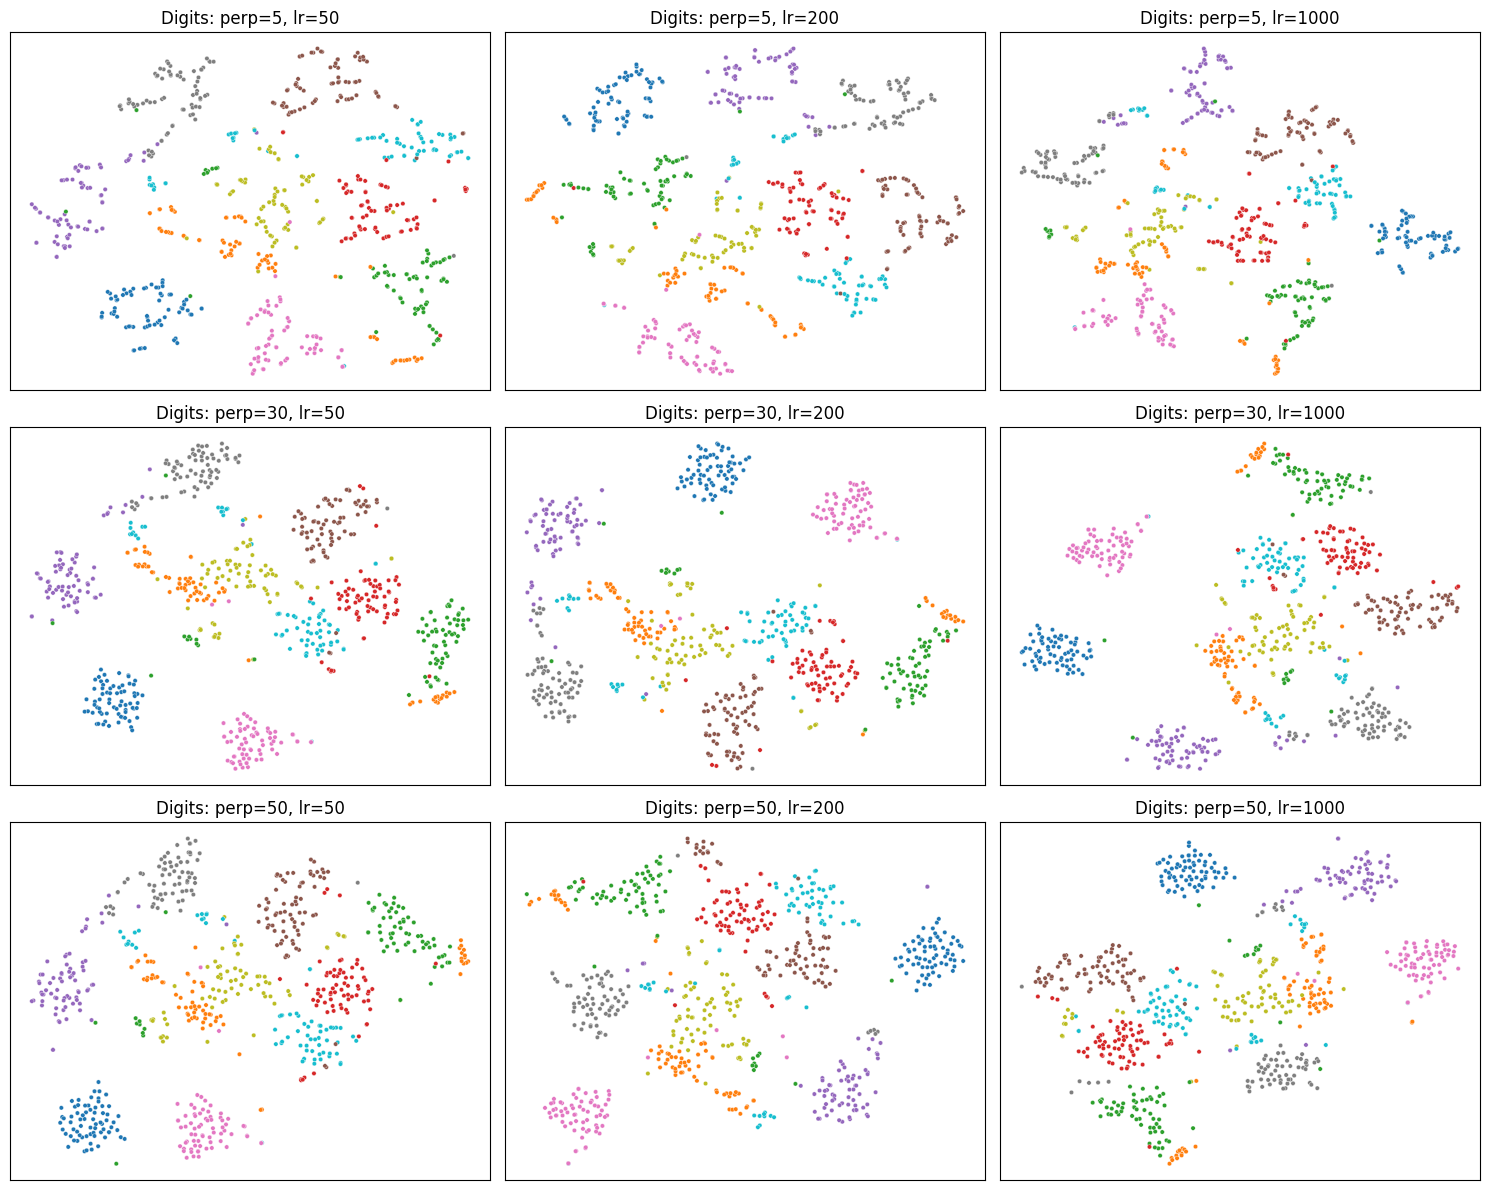

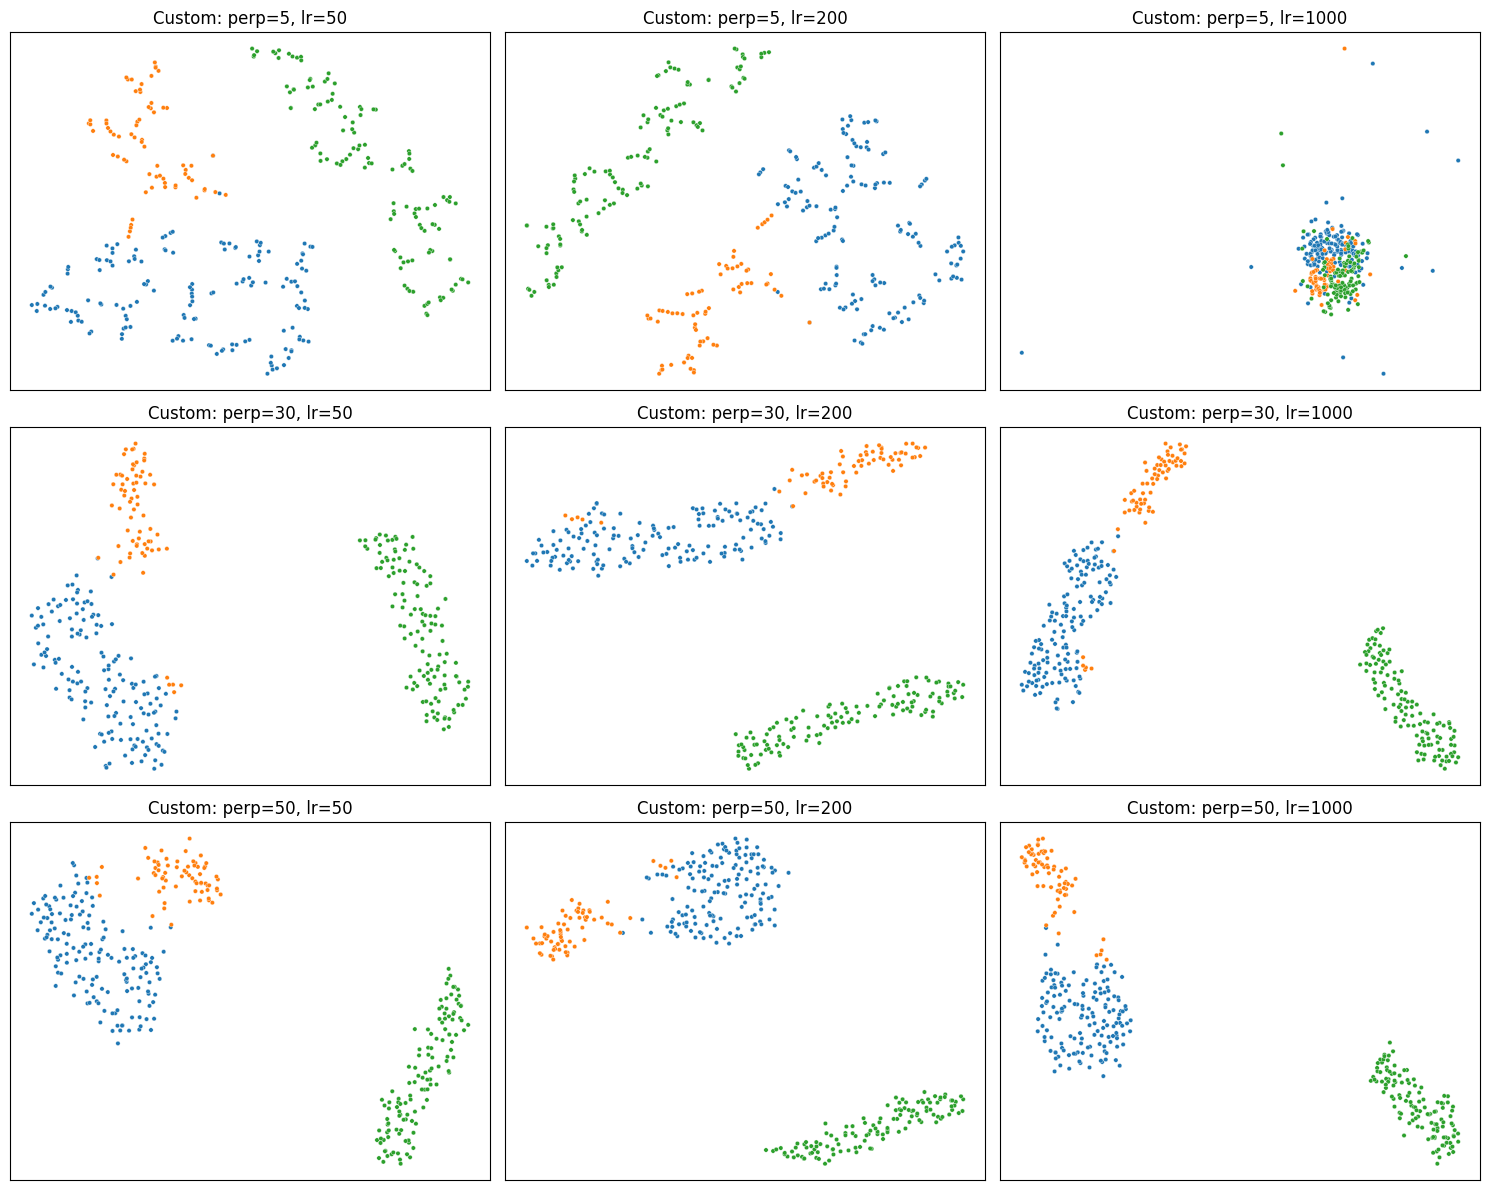

,dataset,perplexity,learning_rate,same,diff,ratio
17,Custom,50,1000,4.507892,36.170044,8.023715
14,Custom,30,1000,9.315571,50.214108,5.390341
16,Custom,50,200,4.390050,23.043974,5.249136
15,Custom,50,50,4.441923,22.887854,5.152691
13,Custom,30,200,7.700437,29.691557,3.855828
12,Custom,30,50,7.459059,28.290701,3.792798
9,Custom,5,50,24.329565,49.713398,2.043333
10,Custom,5,200,25.774105,52.175476,2.024337
11,Custom,5,1000,228.022339,264.474274,1.159861
5,Digits,30,1000,10.415688,32.944202,3.162941


In [19]:
perplexities = [5, 30, 50]
learning_rates = [50, 200, 1000]

def sample_for_tsne(X, y, limit=700):
    if len(X) <= limit:
        return X, y
    counts = pd.Series(y).value_counts()
    stratify = y if counts.min() >= 2 else None
    _, X_part, _, y_part = train_test_split(
        X,
        y,
        test_size=limit,
        random_state=42,
        stratify=stratify
    )
    return X_part, y_part

grid_rows = []

for name, item in prepared.items():
    X_grid, y_grid = sample_for_tsne(item["X_scaled"], item["y"])
    fig, axes = plt.subplots(len(perplexities), len(learning_rates), figsize=(5 * len(learning_rates), 4 * len(perplexities)))

    for i, perp in enumerate(perplexities):
        for j, lr in enumerate(learning_rates):
            current_perp = min(perp, max(1, (len(X_grid) - 1) // 3))
            tsne = make_tsne(perplexity=current_perp, learning_rate=lr, max_iter=500)
            X_emb = tsne.fit_transform(X_grid)
            same, diff, ratio = separation_score(X_emb, y_grid)
            grid_rows.append({"dataset": name, "perplexity": current_perp, "learning_rate": lr, "same": same, "diff": diff, "ratio": ratio})

            ax = axes[i, j]
            sns.scatterplot(x=X_emb[:, 0], y=X_emb[:, 1], hue=y_grid, palette="tab10", s=10, ax=ax, legend=False)
            ax.set_title(f"{name}: perp={current_perp}, lr={lr}")
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()

grid_scores = pd.DataFrame(grid_rows)
grid_scores.sort_values(["dataset", "ratio"], ascending=[True, False])


Проанализируйте:

как меняется форма кластеров,

возникают ли “разрывы” или слияния при разных параметрах,

насколько стабилен рисунок при небольших изменениях параметров.

PCA: устойчивая структура
Для PCA параметров немного (по сути только число компонент), проекция при фиксированном random_state практически не меняется, что показывает устойчивость метода.

Можно показать, что при разных n_components (2, 3, больше) первые две компоненты остаются близкими, а общая структура мало меняется.

In [20]:
pca_10_rows = []

for name, item in prepared.items():
    n_components = min(10, item["X_scaled"].shape[1], item["X_scaled"].shape[0])
    pca_10 = PCA(n_components=n_components, random_state=42)
    X_pca_10 = pca_10.fit_transform(item["X_scaled"])
    pca_10_rows.append({
        "dataset": name,
        "components": n_components,
        "explained_variance_sum": pca_10.explained_variance_ratio_.sum()
    })

pca_10_summary = pd.DataFrame(pca_10_rows)
analysis_summary = pd.DataFrame([
    {"method": "PCA", "result": "устойчивая проекция, лучше показывает глобальную дисперсию"},
    {"method": "t-SNE", "result": "сильнее разделяет локальные группы, чувствителен к perplexity и learning_rate"},
    {"method": "perplexity", "result": "малые значения чаще дробят структуру, большие чаще сглаживают и сближают группы"},
    {"method": "learning_rate", "result": "слишком малые или большие значения могут давать сжатые, разорванные или менее стабильные карты"}
])

display(pca_10_summary)
display(analysis_summary)


,dataset,components,explained_variance_sum
0,Digits,10,0.588738
1,Custom,4,1.000000


,method,result
0,PCA,"устойчивая проекция, лучше показывает глобальн..."
1,t-SNE,"сильнее разделяет локальные группы, чувствител..."
2,perplexity,"малые значения чаще дробят структуру, большие ..."
3,learning_rate,слишком малые или большие значения могут дават...
